# Experiment Tracking with MLflow and the Case-Study Registry

**Chapter 26: MLOps and Governance**
**Docker image**: `ml4t`
**Book Reference**: Chapter 26, Sections 26.1, 26.2, 26.4, 26.6
**Prerequisites**: Basic model evaluation, validation workflows, and Chapter 25 deployment verification.

**Learning Objectives**:
- Read a run log as an experiment tracker: what each row records, how a run is identified,
  and how a result is traced back to the files that produced it.
- Rebuild a searchable catalog of every model run from the tables the pipeline writes, and
  see from it what was tried and what has not been.
- Log the same catalog into MLflow and check that its queries return the same answers, so
  that what a tracker buys can be separated from what the discipline buys.

An **experiment tracker** answers three questions after the fact: what was run, what came
out, and can it be reproduced. The case studies in this book already answer them, through a
SQLite database of runs beside a directory of content-addressed artifact bundles. This
notebook reads that registry first, because seeing the answers assembled by hand is what
makes clear which part MLflow automates.

**Content-addressed** means a run's identifier is a hash of the specification that produced
it, so the same specification always yields the same identifier. That is what makes a run
log idempotent: re-running a pipeline either lands on the row that already exists or
produces a different hash, and there is no third case where two rows describe the same run.

In [1]:
"""Experiment Tracking with MLflow and the Case-Study Registry: one catalog, read two ways."""

'Experiment Tracking with MLflow and the Case-Study Registry: one catalog, read two ways.'

## Settings

`PRIMARY_LABEL` and `SECONDARY_LABEL` name the two return horizons whose runs the catalog
reads. A case study declares several, and reading two of them is enough to show that the
catalog groups by label rather than pooling across horizons.

`MAX_MLFLOW_RUNS` caps how many catalog rows are logged into MLflow. Logging every run would
be the production behaviour and would make this notebook slow; the cap is why the sample is
constructed deliberately below rather than taken off the top.

`PARITY_TOLERANCE` is how far apart the two systems' metrics may be. Both read the same
stored value, so anything above float noise means one of them is reporting a different run.

`BACKTEST_PANEL_ROWS` and `HASH_PREFIX_CHARS` govern how much of the backtest table the
figure shows and how much of each hash labels a bar.

In [2]:
CASE_STUDY_ID = "us_equities_panel"
PRIMARY_LABEL = "fwd_ret_1d"
SECONDARY_LABEL = "fwd_ret_5d"
MAX_MLFLOW_RUNS = 50
PARITY_TOLERANCE = 1e-8
BACKTEST_PANEL_ROWS = 6
HASH_PREFIX_CHARS = 4

In [3]:
import json
import sqlite3
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
from IPython.display import display

from utils.paths import get_case_study_dir, get_output_dir
from utils.style import COLORS, FIGSIZE, add_message_title, ml4t_palette, show_with_alt, zero_line

# Named, not blanket: a bare ignore would also hide the convergence and numerical
# warnings a reader needs to see.
warnings.filterwarnings("ignore", category=FutureWarning, module="mlflow")

CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
REGISTRY_PATH = CASE_DIR / "run_log" / "registry.db"
TRAINING_DIR = CASE_DIR / "run_log" / "training"
PREDICTIONS_DIR = CASE_DIR / "run_log" / "predictions"

print("Experiment Tracking with MLflow and the Case-Study Registry")
print("=" * 60)

Experiment Tracking with MLflow and the Case-Study Registry


## 1. What the registry records

A run log has to carry five things before it can answer the three questions above:
provenance, the data and evaluation protocol, the configuration, the artifacts, and the
decision gates that were applied. The case-study pipeline in Chapters 11 to 16 records them
across three levels, each one a stage of the same experiment:

$$\textrm{training run} \rightarrow \textrm{prediction set} \rightarrow \textrm{backtest run}$$

A training run is a fitted model under one configuration. A prediction set is what that
model produced on one split. A backtest run is what a strategy built from those predictions
did. Each level is identified by a hash of its own canonical specification, and each carries
the identifier of the level above it, so a Sharpe ratio at the bottom resolves to the exact
configuration and data at the top.

In [4]:
from case_studies.utils.registry import REGISTRY_SCHEMA_SQL, canonical_json, compute_hash

print("Registry schema (tables and indexes):")
for line in REGISTRY_SCHEMA_SQL.strip().split("\n"):
    stripped = line.strip()
    if stripped.startswith("CREATE TABLE") or stripped.startswith("CREATE INDEX"):
        print(f"  {stripped.split('(')[0]}")

Registry schema (tables and indexes):
  CREATE TABLE IF NOT EXISTS training_runs 
  CREATE INDEX IF NOT EXISTS idx_training_family_label ON training_runs
  CREATE INDEX IF NOT EXISTS idx_training_config_name ON training_runs
  CREATE TABLE IF NOT EXISTS training_identity_migrations 
  CREATE INDEX IF NOT EXISTS idx_training_migration_source
  CREATE TABLE IF NOT EXISTS prediction_sets 
  CREATE INDEX IF NOT EXISTS idx_pred_training ON prediction_sets
  CREATE INDEX IF NOT EXISTS idx_pred_split ON prediction_sets
  CREATE TABLE IF NOT EXISTS prediction_coverage 
  CREATE TABLE IF NOT EXISTS prediction_metrics 
  CREATE TABLE IF NOT EXISTS fold_metrics 
  CREATE INDEX IF NOT EXISTS idx_fold_metrics_pred ON fold_metrics
  CREATE TABLE IF NOT EXISTS backtest_runs 
  CREATE INDEX IF NOT EXISTS idx_backtest_pred ON backtest_runs
  CREATE INDEX IF NOT EXISTS idx_backtest_stage ON backtest_runs
  CREATE TABLE IF NOT EXISTS backtest_metrics 
  CREATE TABLE IF NOT EXISTS backtest_fold_metrics 
 

### The hash is the identifier

Canonicalizing the specification before hashing is what makes the identifier stable: the
same settings serialize to the same bytes whatever order they were written in, so two runs
of the same experiment collide by design rather than accumulating as separate rows.

In [5]:
example_config = {
    "family": "gbm",
    "label": "fwd_ret_1d",
    "config_name": "leaves_31_mae",
    "seed": 42,
}
example_hash = compute_hash(canonical_json(example_config))
print(f"Config:  {canonical_json(example_config)}")
print(f"Hash:    {example_hash}")
print(f"Stable:  {example_hash == compute_hash(canonical_json(example_config))}")

Config:  {"config_name":"leaves_31_mae","family":"gbm","label":"fwd_ret_1d","seed":42}
Hash:    b7ca6f828792
Stable:  True


MLflow's tracking database holds the same categories under different names: parameters,
metrics, artifact locations and run lineage. The difference is the interface, and the
sections below load the registry directly first so that the comparison in section 7 is
between two answers rather than between an answer and an assumption.

## 2. Load the registry tables

The registry stores the essential experiment-tracking payload across five
tables: `training_runs`, `prediction_sets`, `prediction_metrics`,
`backtest_runs`, and `backtest_metrics`.

In [6]:
def query_table(query: str, params: tuple[object, ...] = ()) -> pd.DataFrame:
    with sqlite3.connect(REGISTRY_PATH) as conn:
        return pd.read_sql_query(query, conn, params=params)

In [7]:
training_runs = query_table(
    """
    SELECT training_hash, family, label, config_name, created_at, spec_json
    FROM training_runs
    WHERE label IN (?, ?)
    """,
    (PRIMARY_LABEL, SECONDARY_LABEL),
)

backtest_runs = query_table(
    """
    SELECT br.backtest_hash, br.prediction_hash, br.spec_json, br.created_at,
           tr.label, tr.family, tr.config_name
    FROM backtest_runs br
    JOIN prediction_sets ps ON br.prediction_hash = ps.prediction_hash
    JOIN training_runs tr ON ps.training_hash = tr.training_hash
    WHERE tr.label IN (?, ?)
    """,
    (PRIMARY_LABEL, SECONDARY_LABEL),
)

print(f"Training runs loaded: {len(training_runs):,}")
print(f"Backtest runs loaded: {len(backtest_runs):,}")

Training runs loaded: 31
Backtest runs loaded: 0


## 3. Build the searchable experiment catalog

Join training runs with their prediction metrics to reconstruct the
experiment catalog that would normally appear in an experiment tracker UI.

In [8]:
run_catalog = query_table(
    """
    SELECT
        tr.training_hash,
        tr.family,
        tr.label,
        tr.config_name,
        tr.created_at,
        ps.prediction_hash,
        ps.split,
        pm.ic_mean_daily AS ic_mean
    FROM training_runs tr
    JOIN prediction_sets ps ON tr.training_hash = ps.training_hash
    LEFT JOIN prediction_metrics pm
        ON ps.prediction_hash = pm.prediction_hash
    WHERE tr.label IN (?, ?)
      AND ps.split = 'validation'
      AND pm.ic_mean_daily IS NOT NULL
      AND pm.ic_n_days > 0
    ORDER BY tr.label, tr.family, pm.ic_mean_daily DESC
    """,
    (PRIMARY_LABEL, SECONDARY_LABEL),
)

print(f"Validation prediction sets: {len(run_catalog):,}")
run_catalog.head(10)

Validation prediction sets: 166


,training_hash,family,label,config_name,created_at,prediction_hash,split,ic_mean
0,f90bffddc549,gbm,fwd_ret_1d,leaves_63_huber,2026-08-18T00:38:55.524294+00:00,f1fb6bdfd651,validation,0.034270
1,f90bffddc549,gbm,fwd_ret_1d,leaves_63_huber,2026-08-18T00:38:55.524294+00:00,2ff717349789,validation,0.033406
2,436ae4650c6c,gbm,fwd_ret_1d,default_huber,2026-08-18T00:38:53.423893+00:00,ddde030bd346,validation,0.033054
3,fd9878609caf,gbm,fwd_ret_1d,leaves_31_huber,2026-08-18T00:38:55.000202+00:00,601faa252443,validation,0.032895
4,436ae4650c6c,gbm,fwd_ret_1d,default_huber,2026-08-18T00:38:53.423893+00:00,7fb749347758,validation,0.032811
5,f90bffddc549,gbm,fwd_ret_1d,leaves_63_huber,2026-08-18T00:38:55.524294+00:00,645dcd378f61,validation,0.032616
6,781b0e40de13,gbm,fwd_ret_1d,leaves_15_huber,2026-08-18T00:38:54.484661+00:00,ccc8fe0e8592,validation,0.032388
7,436ae4650c6c,gbm,fwd_ret_1d,default_huber,2026-08-18T00:38:53.423893+00:00,59870a9a6e0b,validation,0.032354
8,fd9878609caf,gbm,fwd_ret_1d,leaves_31_huber,2026-08-18T00:38:55.000202+00:00,9b06124b6b7c,validation,0.032286
9,a645394a0434,gbm,fwd_ret_1d,leaves_63_mae,2026-08-18T00:38:55.343655+00:00,51c9565f63b8,validation,0.032066


In [9]:
best_validation = (
    run_catalog.sort_values("ic_mean", ascending=False)
    .groupby(["label", "family"], as_index=False)
    .first()
    .sort_values(["label", "ic_mean"], ascending=[True, False])
)
best_validation

,label,family,training_hash,config_name,created_at,prediction_hash,split,ic_mean
0,fwd_ret_1d,gbm,f90bffddc549,leaves_63_huber,2026-08-18T00:38:55.524294+00:00,f1fb6bdfd651,validation,0.034270
1,fwd_ret_1d,linear,8974f3c0c2de,ridge_a1000000.0,2026-08-18T00:12:59.703189+00:00,3f2c8c92d080,validation,0.017989


The catalog answers the first question an experiment review asks: which configurations were
tried, and how did each one score.

What it does not answer is which one to deploy, and the distinction is worth holding onto.
The information coefficient is the rank correlation between a model's scores and the
returns they predicted, so ordering by it says which model ranked the cross-section best -
a description of the predictions. This pipeline selects on validation backtest Sharpe
instead, because a model can rank well and still produce a portfolio nobody would hold once
turnover and costs are charged. The catalog ranks; the selection happens elsewhere.

## 4. What the predictions did as a portfolio

The backtest tables carry what happened when a strategy was built from each prediction set,
which is the evidence the section above cannot supply. Reading it here is also how a
catalog reports a gap: a prediction set with no backtest row is a run that was fitted and
never evaluated as a strategy, and a tracker that only listed what exists would not show
that.

The query is restricted to the equal-weight baseline, which the registry stores under
`stage='signal'`. Every other stage varies an allocator, a cost assumption or a risk overlay
on top of that baseline, and a comparison across stages is a comparison of overlays rather
than of models.

In [10]:
backtest_pivot = query_table(
    """
    SELECT
        tr.family,
        tr.label,
        tr.config_name,
        br.backtest_hash,
        bm.sharpe,
        bm.cagr,
        bm.max_drawdown,
        bm.total_return
    FROM backtest_runs br
    JOIN prediction_sets ps ON br.prediction_hash = ps.prediction_hash
    JOIN training_runs tr ON ps.training_hash = tr.training_hash
    JOIN backtest_metrics bm ON br.backtest_hash = bm.backtest_hash
    WHERE tr.label IN (?, ?)
      AND br.stage = 'signal'
    """,
    (PRIMARY_LABEL, SECONDARY_LABEL),
)

if "sharpe" in backtest_pivot.columns:
    backtest_pivot = backtest_pivot.sort_values("sharpe", ascending=False)

backtest_pivot.head(10)

,family,label,config_name,backtest_hash,sharpe,cagr,max_drawdown,total_return


## 5. Trace one run back to its files

This is the third question - can it be reproduced - and it is the one a metric in a table
cannot answer on its own. The manifest resolves one catalog row to the specification that
configured the fit and the predictions it produced, both addressed by the hashes the row
carries. A missing file here is what a reproducibility claim looks like when it fails.

In [11]:
selected = best_validation.iloc[0]
selected_training_hash = selected["training_hash"]
selected_prediction_hash = selected["prediction_hash"]

training_dir = TRAINING_DIR / selected_training_hash
prediction_dir = PREDICTIONS_DIR / selected_prediction_hash
run_log_display = Path("case_studies") / CASE_STUDY_ID / "run_log"

manifest = pd.DataFrame(
    [
        {
            "artifact": "training spec",
            "path": str(run_log_display / "training" / selected_training_hash / "spec.json"),
            "exists": (training_dir / "spec.json").exists(),
        },
        {
            "artifact": "predictions",
            "path": str(
                run_log_display / "predictions" / selected_prediction_hash / "predictions.parquet"
            ),
            "exists": (prediction_dir / "predictions.parquet").exists(),
        },
    ]
)
manifest

,artifact,path,exists
0,training spec,case_studies/us_equities_panel/run_log/trainin...,True
1,predictions,case_studies/us_equities_panel/run_log/predict...,True


In [12]:
if (training_dir / "spec.json").exists():
    spec = json.loads((training_dir / "spec.json").read_text())
    print(f"Selected training run: {selected_training_hash}")
    print(f"Family: {spec.get('family')}, Config: {spec.get('config_name')}")
    print(f"Label: {spec.get('label')}, Seed: {spec.get('seed')}")
    print(f"Identity version: {spec.get('identity_version')}, Tier: {spec.get('execution_tier')}")
    print(f"\nFull spec:\n{json.dumps(spec, indent=2)}")

if (prediction_dir / "predictions.parquet").exists():
    sample = pl.read_parquet(prediction_dir / "predictions.parquet").head(5)
    print(f"\nSample predictions ({selected_prediction_hash}):")
    display(sample)

Selected training run: f90bffddc549
Family: gbm, Config: leaves_63_huber
Label: fwd_ret_1d, Seed: 42
Identity version: 3, Tier: canonical

Full spec:
{
  "identity_version": 3,
  "resolved_spec_schema": "ml4t.resolved-spec/v1",
  "family": "gbm",
  "label": "fwd_ret_1d",
  "seed": 42,
  "config_name": "leaves_63_huber",
  "execution_tier": "canonical",
  "computation": {
    "checkpoint_schedule": [
      {
        "kind": "iteration",
        "value": 50
      },
      {
        "kind": "iteration",
        "value": 100
      },
      {
        "kind": "iteration",
        "value": 150
      },
      {
        "kind": "iteration",
        "value": 200
      },
      {
        "kind": "iteration",
        "value": 250
      },
      {
        "kind": "iteration",
        "value": 300
      },
      {
        "kind": "iteration",
        "value": 350
      },
      {
        "kind": "iteration",
        "value": 400
      },
      {
        "kind": "iteration",
        "value": 450
    


Sample predictions (f1fb6bdfd651):


symbol,timestamp,fold,prediction,actual
str,date,i64,f64,f64
"""A""",1999-12-22,15,-0.000521,0.046047
"""A""",1999-12-23,15,0.001549,0.061508
"""A""",1999-12-27,15,-0.004361,0.164552
"""A""",1999-12-28,15,-0.007741,0.170732
"""A""",1999-12-29,15,-0.006645,0.100694


## 6. The catalog as a picture

Two things in the catalog are judged by shape rather than read off. How the runs within a
family are distributed says whether a family's best score sits inside a tight cluster or is
one outlier above a spread, which is the difference between a result and a lucky draw. And
the spread of baseline Sharpe across configurations says how much of the strategy's
performance was a choice rather than a property of the signal.

In [13]:
family_counts = run_catalog.groupby(["label", "family"]).size().reset_index(name="run_count")

In [14]:
FAMILY_DISPLAY = {
    "deep_learning": "deep learning",
    "latent_factors": "latent factors",
    "linear": "linear",
    "tabular_dl": "tabular DL",
    "gbm": "GBM",
}


def family_label(name: str) -> str:
    return FAMILY_DISPLAY.get(name, name)

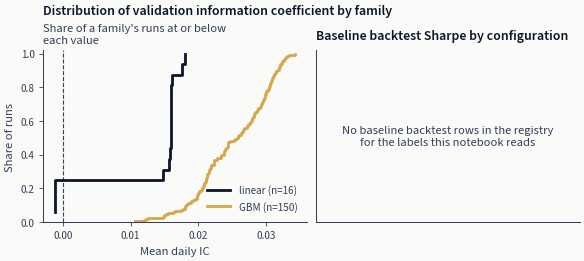

In [15]:
fig, axes = plt.subplots(1, 2, figsize=FIGSIZE["dual_h"], constrained_layout=True)

# An empirical cumulative distribution rather than a strip plot: the families differ by an
# order of magnitude in run count, and a cumulative curve compares their shapes without the
# denser family covering the sparser one.
ax1 = axes[0]
family_order = run_catalog.groupby("family")["ic_mean"].median().sort_values().index.tolist()
family_colors = dict(zip(family_order, ml4t_palette(len(family_order), categorical=True)))
for family_name in family_order:
    values = run_catalog.loc[run_catalog["family"] == family_name, "ic_mean"].sort_values()
    share = np.arange(1, len(values) + 1) / len(values)
    ax1.step(
        values,
        share,
        where="post",
        linewidth=2,
        color=family_colors[family_name],
        label=f"{family_label(family_name)} (n={len(values)})",
    )
zero_line(ax1, axis="x")
ax1.set_ylim(0, 1.02)
add_message_title(
    ax1,
    "Distribution of validation information coefficient by family",
    subtitle="Share of a family's runs at or below each value",
)
ax1.set_xlabel("Mean daily IC")
ax1.set_ylabel("Share of runs")
ax1.legend(loc="lower right", fontsize=8, frameon=False)

ax2 = axes[1]
if backtest_pivot.empty or "sharpe" not in backtest_pivot.columns:
    ax2.text(
        0.5,
        0.5,
        "No baseline backtest rows in the registry\nfor the labels this notebook reads",
        ha="center",
        va="center",
        transform=ax2.transAxes,
    )
    ax2.set_xticks([])
    ax2.set_yticks([])
    add_message_title(ax2, "Baseline backtest Sharpe by configuration")
else:
    shown = backtest_pivot.head(BACKTEST_PANEL_ROWS).sort_values("sharpe")
    ax2.barh(
        shown["config_name"] + " / " + shown["backtest_hash"].str[:HASH_PREFIX_CHARS],
        shown["sharpe"].fillna(0),
        color=COLORS["positive"],
    )
    add_message_title(
        ax2,
        "Baseline backtest Sharpe by configuration",
        subtitle=f"Highest first, at most {BACKTEST_PANEL_ROWS} configurations",
    )
    ax2.set_xlabel("Annualized Sharpe ratio")
    ax2.tick_params(axis="y", labelsize=7)

show_with_alt(
    fig,
    "Two panels. Left: one step curve per model family giving the share of that family's "
    "runs whose mean daily validation information coefficient is at or below each value, "
    "against a dashed vertical line at zero, with the run count in each legend entry. "
    "Right: a horizontal bar chart of baseline backtest Sharpe by configuration, or a note "
    "that the registry holds no baseline backtest rows for these labels.",
)

### Best validation runs

In [16]:
best_validation[["training_hash", "family", "label", "config_name", "ic_mean"]]

,training_hash,family,label,config_name,ic_mean
0,f90bffddc549,gbm,fwd_ret_1d,leaves_63_huber,0.034270
1,8974f3c0c2de,linear,fwd_ret_1d,ridge_a1000000.0,0.017989


One row per family and label, holding the run with the highest mean daily validation IC in
that slice. Grouping before ranking is what keeps the table readable as the catalog grows:
an ungrouped ranking of every run tends to be one family's grid several times over.

### Training run counts by family and label

In [17]:
family_counts

,label,family,run_count
0,fwd_ret_1d,gbm,150
1,fwd_ret_1d,linear,16


How many configurations each family was given, per label. This is the experiment budget,
and it is worth recording because a family that was tried a hundred ways and a family that
was tried twice are not comparable on their best score alone. The more configurations a
search covers, the higher its best score goes on noise, and a catalog that shows only the
leaders hides that entirely.

### Selected run manifest

In [18]:
manifest

,artifact,path,exists
0,training spec,case_studies/us_equities_panel/run_log/trainin...,True
1,predictions,case_studies/us_equities_panel/run_log/predict...,True


## 7. MLflow experiment tracking

Everything above was assembled with SQL written for this schema. MLflow supplies the same
operations as a library - `log_params`, `log_metrics`, `log_artifact` and `search_runs` -
against a schema it owns, with a web interface over it.

The catalog is logged into a local MLflow store below and then queried through its API. The
comparison at the end is the reason to do it: if both return the same runs in the same
order, then what the tracker supplies is the interface and the infrastructure, and the
properties that make either one trustworthy - deterministic hashing, a manifest that
resolves, a recorded specification - came from the pipeline that wrote the runs.

In [19]:
import logging

import mlflow

# MLflow logs schema creation and experiment creation at INFO, on its own logger, and those
# lines land in the committed render as stderr. Raised by name to WARNING, so anything MLflow
# reports as a problem still reaches the reader.
logging.getLogger("mlflow").setLevel(logging.WARNING)

print(f"MLflow {mlflow.__version__} available")

MLflow 3.12.0 available


### Set up a local file-backed tracking store

MLflow writes to a local directory with no server, which is what makes it usable inside a
notebook. The store goes under the chapter's output directory so nothing is written beside
the source.

In [20]:
import shutil

MLFLOW_DIR = get_output_dir(26, "mlflow_tracking")
# A store left by an interrupted execution would return its runs from search_runs too, and
# the parity check below would compare against rows this run never logged.
shutil.rmtree(MLFLOW_DIR, ignore_errors=True)
MLFLOW_DIR.mkdir(parents=True, exist_ok=True)

mlflow.set_tracking_uri(f"sqlite:///{MLFLOW_DIR / 'mlflow.db'}")
experiment = mlflow.set_experiment(CASE_STUDY_ID)
print(f"Tracking URI : {MLFLOW_DIR}")
print(f"Experiment   : {experiment.name} (id={experiment.experiment_id})")

Tracking URI : ~/ml4t/public-teach-g/26_mlops_governance/output/mlflow_tracking
Experiment   : us_equities_panel (id=1)


### Log catalog runs into MLflow

The sample is constructed rather than sliced. Every row that tops its family-label group
goes in first, and the remaining slots go to the highest-IC runs left over.

The construction is what makes the check at the end mean something. Under a plain top-N
slice, a group whose best run sits outside the global top `MAX_MLFLOW_RUNS` reaches the
manual catalog and not MLflow, and the comparison then reports a difference the sampling
created.

In [21]:
def log_catalog_to_mlflow(catalog: pd.DataFrame, max_runs: int = MAX_MLFLOW_RUNS) -> int:
    """Log catalog rows as MLflow runs, returning how many were logged.

    A production pipeline logs one run as each training job finishes, so the cap exists
    only to keep this notebook fast.
    """
    logged = 0
    for row in catalog.itertuples(index=False):
        if logged >= max_runs:
            break
        ic = row.ic_mean
        if ic is None or (isinstance(ic, float) and pd.isna(ic)):
            continue

        with mlflow.start_run(run_name=row.training_hash):
            params = {"family": str(row.family), "label": str(row.label)}
            if row.config_name is not None:
                params["config_name"] = str(row.config_name)
            mlflow.log_params(params)

            metrics = {"ic_mean_daily": float(ic)}
            mlflow.log_metrics(metrics)

            spec_path = TRAINING_DIR / row.training_hash / "spec.json"
            if spec_path.exists():
                mlflow.log_artifact(str(spec_path))

        logged += 1
    return logged


leader_hashes = set(best_validation["training_hash"])
leaders = run_catalog[run_catalog["training_hash"].isin(leader_hashes)]
remaining = run_catalog[~run_catalog["training_hash"].isin(leader_hashes)].sort_values(
    "ic_mean", ascending=False
)
catalog_sample = pd.concat([leaders, remaining], ignore_index=True).head(MAX_MLFLOW_RUNS)
assert leader_hashes.issubset(set(catalog_sample["training_hash"]))
n_logged = log_catalog_to_mlflow(catalog_sample, max_runs=len(catalog_sample))
assert n_logged == len(catalog_sample)
print(f"Logged {n_logged} runs into MLflow experiment '{CASE_STUDY_ID}'")

Logged 50 runs into MLflow experiment 'us_equities_panel'


### Query runs with `search_runs`

`search_runs` returns a DataFrame whose columns are prefixed by `params.` and `metrics.`,
reflecting how MLflow stores them: parameters are strings it does not interpret, metrics are
numbers it can order and filter by. That split is a modelling decision the caller makes at
logging time, and it decides what can be queried later.

In [22]:
all_runs = mlflow.search_runs(
    experiment_names=[CASE_STUDY_ID],
    order_by=["metrics.ic_mean_daily DESC"],
)
print(f"Total runs tracked: {len(all_runs)}")
all_runs[
    [
        "run_id",
        "tags.mlflow.runName",
        "params.family",
        "params.label",
        "metrics.ic_mean_daily",
    ]
].head(10)

Total runs tracked: 50


,run_id,tags.mlflow.runName,params.family,params.label,metrics.ic_mean_daily
0,aa1a6c55d5e54fa4a77f9bab9fa80de2,f90bffddc549,gbm,fwd_ret_1d,0.034270
1,531c25c815364b0ba0e2e6de429f6cae,f90bffddc549,gbm,fwd_ret_1d,0.033406
2,8431428f20a64abfbbfe576a58e0d5f4,436ae4650c6c,gbm,fwd_ret_1d,0.033054
3,486e0db6cee247a6a324f5ad8e4e8dea,fd9878609caf,gbm,fwd_ret_1d,0.032895
4,9b3bfef9eee049a8ac3b3affaa639d33,436ae4650c6c,gbm,fwd_ret_1d,0.032811
5,04f71f38d3974d399ce67b1fb9ef6df4,f90bffddc549,gbm,fwd_ret_1d,0.032616
6,05f2003b2de94693a76b73053b4d111e,781b0e40de13,gbm,fwd_ret_1d,0.032388
7,444b65683d85485698d42cf7cf5a1756,436ae4650c6c,gbm,fwd_ret_1d,0.032354
8,1c03218978774a70892e6559c2c48f21,fd9878609caf,gbm,fwd_ret_1d,0.032286
9,d25e71be120646f38c346056a881855f,a645394a0434,gbm,fwd_ret_1d,0.032066


### Filter by family

`filter_string` takes SQL-like predicates over the same parameters and metrics, which is the
operation the grouped ranking in section 3 performed with a `GROUP BY`.

In [23]:
gbm_runs = mlflow.search_runs(
    experiment_names=[CASE_STUDY_ID],
    filter_string="params.family = 'gbm'",
    order_by=["metrics.ic_mean_daily DESC"],
)
print(f"GBM runs: {len(gbm_runs)}")
gbm_runs[
    [
        "tags.mlflow.runName",
        "params.label",
        "params.config_name",
        "metrics.ic_mean_daily",
    ]
].head(10)

GBM runs: 49


,tags.mlflow.runName,params.label,params.config_name,metrics.ic_mean_daily
0,f90bffddc549,fwd_ret_1d,leaves_63_huber,0.034270
1,f90bffddc549,fwd_ret_1d,leaves_63_huber,0.033406
2,436ae4650c6c,fwd_ret_1d,default_huber,0.033054
3,fd9878609caf,fwd_ret_1d,leaves_31_huber,0.032895
4,436ae4650c6c,fwd_ret_1d,default_huber,0.032811
5,f90bffddc549,fwd_ret_1d,leaves_63_huber,0.032616
6,781b0e40de13,fwd_ret_1d,leaves_15_huber,0.032388
7,436ae4650c6c,fwd_ret_1d,default_huber,0.032354
8,fd9878609caf,fwd_ret_1d,leaves_31_huber,0.032286
9,a645394a0434,fwd_ret_1d,leaves_63_mae,0.032066


### Verify ranking parity with the manual catalog

The comparison is an outer join on family and label, so a group present in one system and
absent from the other fails rather than being dropped. Both the identity of each group's
top run and its metric are checked, because agreeing on the number while disagreeing on
which run produced it is the more interesting failure.

In [24]:
mlflow_best = (
    all_runs.sort_values("metrics.ic_mean_daily", ascending=False)
    .groupby(["params.label", "params.family"], as_index=False)
    .first()
)
mlflow_best_compact = mlflow_best.rename(
    columns={
        "tags.mlflow.runName": "training_hash",
        "params.family": "family",
        "params.label": "label",
        "metrics.ic_mean_daily": "ic_mean",
    }
)[["training_hash", "family", "label", "ic_mean"]].sort_values(
    ["label", "ic_mean"], ascending=[True, False]
)

manual_best_compact = best_validation[["training_hash", "family", "label", "ic_mean"]].sort_values(
    ["label", "ic_mean"], ascending=[True, False]
)

comparison = mlflow_best_compact.merge(
    manual_best_compact,
    on=["family", "label"],
    how="outer",
    suffixes=("_mlflow", "_manual"),
    indicator=True,
)
comparison["ic_match"] = (
    comparison["ic_mean_mlflow"] - comparison["ic_mean_manual"]
).abs() < PARITY_TOLERANCE
comparison["hash_match"] = comparison["training_hash_mlflow"] == comparison["training_hash_manual"]
assert (comparison["_merge"] == "both").all()
assert comparison[["ic_match", "hash_match"]].all().all()
print("Ranking parity check (MLflow vs manual catalog):")
comparison

Ranking parity check (MLflow vs manual catalog):


,training_hash_mlflow,family,label,ic_mean_mlflow,training_hash_manual,ic_mean_manual,_merge,ic_match,hash_match
0,f90bffddc549,gbm,fwd_ret_1d,0.034270,f90bffddc549,0.034270,both,True,True
1,8974f3c0c2de,linear,fwd_ret_1d,0.017989,8974f3c0c2de,0.017989,both,True,True


The assertions above are what make this a check: the notebook stops if any group is missing
from either side, or if the two disagree about which run tops it or by how much.

What that establishes is that MLflow's query returns the catalog it was given. It is a test
of the logging and of the query, and it says nothing about whether the metric is the right
one to rank on - which section 3 already answered, and the answer was no.

### Clean up

The tracking store was written under this chapter's output directory and is removed here. A
production store persists and is shared, which is most of what makes it a tracker rather
than a log file.

In [25]:
shutil.rmtree(MLFLOW_DIR, ignore_errors=True)
print(f"Cleaned up tracking store: {MLFLOW_DIR}")

Cleaned up tracking store: ~/ml4t/public-teach-g/26_mlops_governance/output/mlflow_tracking


## Key Takeaways

1. An experiment tracker has to answer three questions - what was run, what came out, and
   can it be reproduced - and the third is the one a table of metrics cannot answer alone.
   A row that resolves to the specification and the artifacts is the difference between a
   record and a claim.
2. Identify a run by a hash of its specification. That makes the log idempotent, so
   re-running a pipeline cannot produce two rows describing the same experiment, and it
   makes a configuration change visible as a new identifier rather than as an edit.
3. Record the experiment budget, not only the results. A family tried a hundred ways and a
   family tried twice are not comparable on their best score, because the more
   configurations a search covers the higher its best score climbs on noise alone.
4. Keep ranking separate from selection. Ordering the catalog by information coefficient
   says which model ranked the cross-section best; it is not what decides deployment, and a
   tracker that presents one ordering invites it to become the other.
5. The tool supplies the interface and the infrastructure; the discipline supplies the
   trust. Deterministic identifiers, a manifest that resolves and a recorded specification
   are properties of the pipeline that writes the runs, and MLflow reproduces this catalog
   exactly because they were already there.

**Known limitations**

- The parity check covers the runs that were logged, on one case study, with one metric. It
  establishes that the query returns the catalog it was given, not that either system is
  correctly configured for a catalog with a different shape.
- The tracking store here is local, single-user and deleted at the end. Multi-user
  collaboration, access control and a persistent web interface are most of what MLflow is
  chosen for, and none of them is exercised.
- The catalog reads two labels from one case study. A registry-wide view would also have to
  reconcile runs across case studies, which have their own registries.

**Next**: This is the final notebook of Chapter 26. The chapter prose closes with the
three-layer governance model - detection, response, automated safety - which together with
the MLOps components in these notebooks keep a deployed strategy auditable.